In [1]:
%pip install -U langgraph langchain-community langchain-google-genai langchain-ollama wikipedia arxiv duckduckgo-search ddgs requests

  Using cached arxiv-4.0.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
Using cached requests-2.34.2-py3-none-any.whl (73 kB)
Using cached arxiv-4.0.1-py3-none-any.whl (13 kB)

  Attempting uninstall: requests

    Found existing installation: requests 2.32.5

    Uninstalling requests-2.32.5:

      Successfully uninstalled requests-2.32.5

   ---------------------------------------- 0/2 [requests]
  Attempting uninstall: arxiv
   ---------------------------------------- 0/2 [requests]
    Found existing installation: arxiv 2.1.3
   ---------------------------------------- 0/2 [requests]
    Uninstalling arxiv-2.1.3:
   ---------------------------------------- 0/2 [requests]
      Successfully uninstalled arxiv-2.1.3
   ---------------------------------------- 0/2 [requests]
   -------------------- ------------------- 1/2 [arxiv]
   ---------------------------------------- 2/2 [arxiv]

Note: you may need to restart the kernel to 

In [2]:
%pip install "arxiv==2.1.3"

  Using cached arxiv-2.1.3-py3-none-any.whl.metadata (6.1 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
Using cached arxiv-2.1.3-py3-none-any.whl (11 kB)
Using cached requests-2.32.5-py3-none-any.whl (64 kB)

  Attempting uninstall: requests

    Found existing installation: requests 2.34.2

    Uninstalling requests-2.34.2:

      Successfully uninstalled requests-2.34.2

   ---------------------------------------- 0/2 [requests]
  Attempting uninstall: arxiv
   ---------------------------------------- 0/2 [requests]
    Found existing installation: arxiv 4.0.1
   ---------------------------------------- 0/2 [requests]
    Uninstalling arxiv-4.0.1:
   ---------------------------------------- 0/2 [requests]
      Successfully uninstalled arxiv-4.0.1
   ---------------------------------------- 0/2 [requests]
   ---------------------------------------- 2/2 [arxiv]

Note: you may need to restart the kernel to use updated packages.


In [3]:
from datetime import date
from getpass import getpass

import requests

from langchain_core.tools import tool
from langchain_core.messages import SystemMessage

from langchain_ollama import ChatOllama
from langchain_google_genai import ChatGoogleGenerativeAI

from langchain_community.tools import (
    WikipediaQueryRun,
    ArxivQueryRun,
    DuckDuckGoSearchRun,
)

from langchain_community.utilities import (
    WikipediaAPIWrapper,
    ArxivAPIWrapper,
)

from langgraph.graph import StateGraph, MessagesState, START
from langgraph.prebuilt import ToolNode, tools_condition

C:\Users\Acer\AppData\Local\Temp\ipykernel_22564\915841508.py:12: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import (


In [4]:
wikipedia_tool = WikipediaQueryRun(
    api_wrapper=WikipediaAPIWrapper(
        top_k_results=1,
        doc_content_chars_max=1500,
    )
)

arxiv_tool = ArxivQueryRun(
    api_wrapper=ArxivAPIWrapper(
        top_k_results=1,
        doc_content_chars_max=1500,
    )
)

search_tool = DuckDuckGoSearchRun()

In [5]:
@tool
def calculate_age(birth_date: str) -> str:
    """Calculate age from a birth date in YYYY-MM-DD format."""

    try:
        birthday = date.fromisoformat(birth_date)
    except ValueError:
        return "Please provide a valid birth date in YYYY-MM-DD format."

    today = date.today()

    if birthday > today:
        return "Birth date cannot be in the future."

    age = today.year - birthday.year

    if (today.month, today.day) < (birthday.month, birthday.day):
        age -= 1

    return f"Age: {age} years, as of {today}."

In [6]:
@tool
def get_weather(city: str) -> str:
    """Get current weather for a city, such as Dhaka or Tokyo."""

    try:
        # Find the city's coordinates.
        response = requests.get(
            "https://geocoding-api.open-meteo.com/v1/search",
            params={"name": city, "count": 1},
            timeout=20,
        )
        response.raise_for_status()

        locations = response.json().get("results", [])

        if not locations:
            return f"City not found: {city}"

        location = locations[0]

        # Get weather for those coordinates.
        response = requests.get(
            "https://api.open-meteo.com/v1/forecast",
            params={
                "latitude": location["latitude"],
                "longitude": location["longitude"],
                "current": "temperature_2m,relative_humidity_2m",
                "timezone": "auto",
            },
            timeout=20,
        )
        response.raise_for_status()

        weather = response.json()["current"]

        return (
            f"Location: {location['name']}, "
            f"{location.get('country', '')}\n"
            f"Time: {weather['time']}\n"
            f"Temperature: {weather['temperature_2m']} °C\n"
            f"Humidity: {weather['relative_humidity_2m']}%\n"
            f"Source: Open-Meteo"
        )

    except (requests.RequestException, KeyError, ValueError) as error:
        return f"Could not retrieve weather: {error}"

In [7]:
tools = [
    wikipedia_tool,
    arxiv_tool,
    search_tool,
    calculate_age,
    get_weather,
]

print(calculate_age.invoke({"birth_date": "2000-05-15"}))

print(get_weather.invoke({"city": "Dhaka"}))

Age: 26 years, as of 2026-09-16.
Location: Dhaka, Bangladesh
Time: 2026-09-16T23:00
Temperature: 26.5 °C
Humidity: 90%
Source: Open-Meteo


In [8]:
local_llm = ChatOllama(
    model="llama3.2",
    temperature=0,
    num_ctx=8192,
    client_kwargs={"timeout": 180},
)

print(local_llm.invoke("Say hello in one sentence.").content)

Hello!


In [9]:
gemini_llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    api_key=getpass("Enter your Gemini API key: "),
    vertexai=False,
    temperature=0,
    thinking_budget=0,
    timeout=60,
    max_retries=0,
)

print(gemini_llm.invoke("Say hello in one sentence.").content)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Hello!


In [29]:
def build_agent(llm):
    llm_with_tools = llm.bind_tools(tools)

    def chatbot(state: MessagesState):
        instructions = SystemMessage(
            content=(
                "You are a helpful assistant. "
                "Use a tool only when it is needed to answer the user's question. "
                "For greetings, casual conversation, and simple explanations, "
                "answer directly WITHOUT calling any tool. "
                "For example, 'Hello! How are you?' needs only a friendly reply. "
                "Use the weather tool only when the user asks about weather. "
                "Use the age calculator only when the user asks for an age. "
                "Use search tools only when the question needs a lookup. "
                "Never invent tool inputs such as a city or birth date. "
                "If a required input is missing, ask the user. "
                "Base your final answer on the actual tool results. "
                "If a tool fails, explain the failure and stop."
            )
        )

        response = llm_with_tools.invoke(
            [instructions] + state["messages"]
        )

        return {"messages": [response]}

    graph = StateGraph(MessagesState)

    graph.add_node("chatbot", chatbot)
    graph.add_node(
        "tools",
        ToolNode(tools, handle_tool_errors=True),
    )

    graph.add_edge(START, "chatbot")

    graph.add_conditional_edges(
        "chatbot",
        tools_condition,
    )

    graph.add_edge("tools", "chatbot")

    return graph.compile()

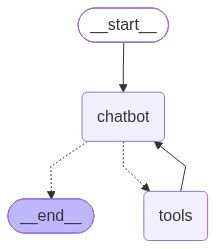

In [27]:
local_agent = build_agent(local_llm)

from IPython.display import Image, display

display(Image(local_agent.get_graph().draw_mermaid_png()))

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	chatbot(chatbot)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> chatbot;
	chatbot -.-> __end__;
	chatbot -.-> tools;
	tools --> chatbot;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [30]:
local_agent = build_agent(local_llm)
gemini_agent = build_agent(gemini_llm)


def ask(agent, question):
    for state in agent.stream(
        {"messages": [("user", question)]},
        config={"recursion_limit": 10},
        stream_mode="values",
    ):
        state["messages"][-1].pretty_print()

In [39]:
ask(
    local_agent,
    "Find the research paper Attention Is All You Need.",
)

================================ Human Message =================================

Find the research paper Attention Is All You Need.
================================== Ai Message ==================================
Tool Calls:
  arxiv (b354d034-fa92-4f28-b4bd-c7a1ba34dcc3)
 Call ID: b354d034-fa92-4f28-b4bd-c7a1ba34dcc3
  Args:
    query: Attention Is All You Need
================================= Tool Message =================================
Name: arxiv

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in 

In [38]:
ask(
    local_agent,
    "I was born on 2000-05-15. How old am I today?",
)

================================ Human Message =================================

I was born on 2000-05-15. How old am I today?
================================== Ai Message ==================================
Tool Calls:
  calculate_age (3d22a19e-9be4-4cf5-ac6c-0df990f479af)
 Call ID: 3d22a19e-9be4-4cf5-ac6c-0df990f479af
  Args:
    birth_date: 2000-05-15
================================= Tool Message =================================
Name: calculate_age

Age: 26 years, as of 2026-09-16.
================================== Ai Message ==================================

You are 26 years old today.


In [37]:
ask(
    local_agent,
    "Look up Albert Einstein on Wikipedia and summarize his life.",
)

================================ Human Message =================================

Look up Albert Einstein on Wikipedia and summarize his life.
================================== Ai Message ==================================
Tool Calls:
  wikipedia (c06cef81-512f-4c15-9b6b-ac309f81056c)
 Call ID: c06cef81-512f-4c15-9b6b-ac309f81056c
  Args:
    query: Albert Einstein
================================= Tool Message =================================
Name: wikipedia

Page: Albert Einstein
Summary: Albert Einstein (14 March 1879 – 18 April 1955) was a German-born theoretical physicist best known for developing the theory of relativity. Einstein also made important contributions to quantum theory. His mass–energy equivalence formula E = mc2, which arises from special relativity, has been called "the world's most famous equation". He received the 1921 Nobel Prize in Physics for "his services to theoretical physics, and especially for his discovery of the law of the photoelectric effect".
Born 

In [32]:
ask(
    local_agent,
    "Find the latest news about NVIDIA today and include source links.",
)

================================ Human Message =================================

Find the latest news about NVIDIA today and include source links.
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (c776e61f-6581-4f8a-8721-0b28147fac0f)
 Call ID: c776e61f-6581-4f8a-8721-0b28147fac0f
  Args:
    query: NVIDIA latest news today with source links
================================= Tool Message =================================
Name: duckduckgo_search

NVIDIA Expands Open Source CUDA-Q Platform for Fault-Tolerant Quantum Computing NVIDIA today announced an expansion of the NVIDIA CUDA-Q™ open source platform with CUDA-Q Logical, an orchestration layer that provides a programmable, verifiable approach to developing useful applications for fault-tolerant quantum computers. Air pollution is a serious public health risk, contributing to an estimated 30,000 deaths in the U.K. alone last year. Data-driven insights can help — but compu

In [31]:
ask(
    local_agent,
    "Hello! How are you?",
)

================================ Human Message =================================

Hello! How are you?
================================== Ai Message ==================================

I'm doing well, thank you for asking! How can I assist you today?


In [40]:
ask(gemini_agent, "Hello! How are you?")

================================ Human Message =================================

Hello! How are you?
================================== Ai Message ==================================

Hello! I'm doing well, thank you. How can I help you today?


In [41]:
ask(gemini_agent, "What is the current temperature in Dhaka?")

================================ Human Message =================================

What is the current temperature in Dhaka?
================================== Ai Message ==================================
Tool Calls:
  get_weather (32a2adf0-9da5-4231-b519-4c3f4c46ebd7)
 Call ID: 32a2adf0-9da5-4231-b519-4c3f4c46ebd7
  Args:
    city: Dhaka
================================= Tool Message =================================
Name: get_weather

Location: Dhaka, Bangladesh
Time: 2026-09-16T23:15
Temperature: 26.4 °C
Humidity: 90%
Source: Open-Meteo
================================== Ai Message ==================================

The current temperature in Dhaka is 26.4°C with 90% humidity.


In [42]:
ask(gemini_agent, "I was born on 2000-05-15. How old am I today?")

================================ Human Message =================================

I was born on 2000-05-15. How old am I today?
================================== Ai Message ==================================
Tool Calls:
  calculate_age (4715cbcc-9cf5-4728-83bf-1e047f60cacb)
 Call ID: 4715cbcc-9cf5-4728-83bf-1e047f60cacb
  Args:
    birth_date: 2000-05-15
================================= Tool Message =================================
Name: calculate_age

Age: 26 years, as of 2026-09-16.
================================== Ai Message ==================================

You are 26 years old, as of 2026-09-16.


In [55]:
ask(gemini_agent, "Look up Albert Einstein on Wikipedia and summarize his life.")

================================ Human Message =================================

Look up Albert Einstein on Wikipedia and summarize his life.
================================== Ai Message ==================================
Tool Calls:
  wikipedia (b84f052d-6e0f-4ca7-929c-d377e413a086)
 Call ID: b84f052d-6e0f-4ca7-929c-d377e413a086
  Args:
    query: Albert Einstein
================================= Tool Message =================================
Name: wikipedia

Page: Albert Einstein
Summary: Albert Einstein (14 March 1879 – 18 April 1955) was a German-born theoretical physicist best known for developing the theory of relativity. Einstein also made important contributions to quantum theory. His mass–energy equivalence formula E = mc2, which arises from special relativity, has been called "the world's most famous equation". He received the 1921 Nobel Prize in Physics for "his services to theoretical physics, and especially for his discovery of the law of the photoelectric effect".
Born 

In [56]:
ask(gemini_agent, "Find the research paper Attention Is All You Need.")

================================ Human Message =================================

Find the research paper Attention Is All You Need.
================================== Ai Message ==================================
Tool Calls:
  arxiv (30cae665-8385-4151-a4df-b4f114ddcd49)
 Call ID: 30cae665-8385-4151-a4df-b4f114ddcd49
  Args:
    query: Attention Is All You Need
================================= Tool Message =================================
Name: arxiv

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in 

In [90]:
question = input("Ask a question: ")

result = local_agent.invoke(
    {"messages": [("user", question)]},
    config={"recursion_limit": 10},
)

print(result["messages"][-1].content)

The current temperature in Paris is 20.8 degrees Celsius.
